In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [542]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [346]:
def plot_histogram(df, prop, labels=None, bins=100, log=True):
    labelsize = 55
    x_tick_major_size = 16
    x_tick_major_width = 4
    x_tick_minor_size = 8
    x_tick_minor_width = 3
    fig_width = 25
    fig_height = 15
    axes_width = 3
    tick_labelsize = 35
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    
    if labels == None:
        if prop == 'Column_dens_r':
            x_label = r'$\log(\rho)[\log(\mathrm{gcm}^{-3})]$'
            y_label = r'p.d.f.($\log(\rho)$)'
            labels = {'x':x_label, 'y':y_label}
        elif prop == 'Column_height_r':
            x_label = '$\log(h)[\log(\mathrm{cm})]$'
            y_label = r'p.d.f.($\log(h)$)'
            labels = {'x':x_label, 'y':y_label}
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    ax.set_xlabel(labels['x'], size=labelsize)
    ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [761]:
!ls -l /ptmp/mpa/ivkos/semianalytic_fesc/sn013/

total 1833218
-rw-r--r-- 1 ivkos mpa    6075279 Jul 25 16:08 0_df.pickle
-rw-r--r-- 1 ivkos mpa       2038 Jul 25 18:19 0_test_df.pickle
-rw-r--r-- 1 ivkos mpa    7730704 Jul 25 21:47 1_df.pickle
-rw-r--r-- 1 ivkos mpa       2051 Jul 25 18:07 1_test_df.pickle
-rw-r--r-- 1 ivkos mpa       2946 Jul 25 18:22 2_df.pickle
-rw-r--r-- 1 ivkos mpa   38265452 Jul 20 12:25 dataset_reduced.pickle
-rw-r--r-- 1 ivkos mpa 1701367443 Jul 18 17:29 full_dataset.pickle
-rw-r--r-- 1 ivkos mpa    6075279 Jul 25 16:01 reduced_df.pickle
-rw-r--r-- 1 ivkos mpa   63024272 Jul 20 15:20 reduced_df_update1.pickle
-rw-r--r-- 1 ivkos mpa   53640545 Jul 23 16:01 reduced_df_update2.pickle


In [760]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/1_adf.pickle'
df_new = pd.read_pickle(df_path)

In [762]:
df_new

,Z_2r,Z_r,r,SFR_r,SFR_2r,Halo_pos_x,Halo_pos_y,Halo_pos_z,M_gas_2r,V_2r,M_star_2r,M_gas_r,V_r,M_star_r,Redshift
0,0.015532,0.017928,3.869927e+20,224.748779,391.632721,24135.921875,18115.128906,14856.313477,2.026456e+43,2.075204e+63,6.769819e+43,9.602611e+42,2.437948e+62,4.052734e+43,6.010757
1,0.002725,0.003610,5.800949e+21,1.461907,1.798865,24471.667969,18013.396484,14240.319336,3.518825e+42,5.830417e+66,3.538731e+41,2.046294e+42,8.532886e+65,2.578326e+41,6.010757
2,0.004793,0.007448,3.989575e+21,0.276816,0.346269,24264.136719,18214.417969,14564.745117,8.444093e+41,2.076352e+66,1.932071e+41,4.509880e+41,2.802983e+65,1.555569e+41,6.010757
3,0.001956,0.003759,8.652754e+21,0.078287,0.122709,24364.863281,18031.574219,14490.092773,1.240146e+42,1.221089e+67,9.452060e+40,4.037105e+41,2.078697e+66,6.436025e+40,6.010757
4,0.005315,0.007526,3.595354e+21,0.087283,0.115020,24437.298828,17996.375000,14386.402344,4.167847e+41,1.632483e+66,9.387866e+40,2.293875e+41,2.252844e+65,6.876274e+40,6.010757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1388301,0.001737,0.001838,1.015656e+21,0.000260,0.000577,15627.953125,22236.148438,681.524597,8.599949e+39,3.961409e+64,1.069374e+39,1.716710e+39,6.073829e+63,6.281820e+38,6.010757
1430219,0.003099,0.003106,1.210469e+21,0.000043,0.000043,30536.013672,11312.036133,19243.048828,4.682331e+39,9.847989e+64,1.009858e+39,1.851126e+39,1.594272e+64,4.341830e+38,6.010757
1466321,0.000674,0.001148,2.477648e+21,0.000019,0.000019,4289.094238,30064.287109,8729.732422,3.292971e+40,5.587762e+65,1.059016e+39,7.204560e+39,7.214824e+64,3.895352e+38,6.010757
1654749,0.000899,0.001071,2.427863e+21,0.000081,0.000081,22023.445312,13722.003906,2559.345459,2.587759e+40,4.592227e+65,1.119593e+39,8.280264e+39,7.588489e+64,6.135523e+38,6.010757


In [757]:
test_df = df_new[1000:1010]

In [758]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/0_test_df.pickle'
test_df.to_pickle(df_path)

In [650]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/reduced_df_update2.pickle'
df = pd.read_pickle(df_path)

In [651]:
test_df = df.iloc[1000:10000].copy(deep=True)

In [465]:
from calculate_fesc import update_to_fesc

In [490]:
from astropy import units as u

In [755]:
df_new

,Z_2r,Z_r,r,M_gas_r,M_gas_2r,M_star_r,M_star_2r,SFR_r,SFR_2r,Halo_pos_x,Halo_pos_y,Halo_pos_z
16446,0.000648,0.000000,2.295144,0.000000,0.000007,0.000115,0.000213,0.000000,0.000041,8827.685547,7878.967773,3662.097900
16448,0.001438,0.001454,6.615229,0.000424,0.000464,0.000023,0.000034,0.000213,0.000213,8348.710938,8258.840820,3490.534912
16590,0.005930,0.008922,5.280626,0.035050,0.062682,0.017526,0.022213,1.322023,1.607253,13801.541016,21996.103516,12093.393555
16591,0.003472,0.004619,4.932633,0.007910,0.012976,0.001449,0.001991,0.104602,0.124456,13820.692383,22215.908203,12060.691406
16592,0.001348,0.001933,4.181373,0.002066,0.004844,0.000208,0.000294,0.016704,0.025625,13815.258789,22304.767578,12083.934570
16593,0.002825,0.003438,3.561630,0.002500,0.005472,0.000465,0.000680,0.027537,0.040448,13856.641602,21927.458984,12061.734375
16594,0.005630,0.005972,3.049335,0.003579,0.007772,0.000778,0.001420,0.077735,0.159794,13784.235352,22013.246094,12091.250977
16595,0.000463,0.000412,3.543985,0.000470,0.001780,0.000026,0.000050,0.001701,0.003146,13899.190430,22233.029297,12130.987305
16596,0.000482,0.000439,5.943006,0.000979,0.003170,0.000034,0.000069,0.002216,0.004213,13903.108398,21908.619141,12038.123047
16597,0.001657,0.001573,2.244422,0.000160,0.000741,0.000034,0.000049,0.000735,0.001595,13879.061523,22235.363281,12100.083008


In [737]:
!ls -l /ptmp/mpa/ivkos/semianalytic_fesc/sn013

total 1825536
-rw-r--r-- 1 ivkos mpa    6075279 Jul 25 16:08 0_df.pickle
-rw-r--r-- 1 ivkos mpa   38265452 Jul 20 12:25 dataset_reduced.pickle
-rw-r--r-- 1 ivkos mpa 1701367443 Jul 18 17:29 full_dataset.pickle
-rw-r--r-- 1 ivkos mpa    6075279 Jul 25 16:01 reduced_df.pickle
-rw-r--r-- 1 ivkos mpa   63024272 Jul 20 15:20 reduced_df_update1.pickle
-rw-r--r-- 1 ivkos mpa   53640545 Jul 23 16:01 reduced_df_update2.pickle


In [738]:
df_path = '/ptmp/mpa/ivkos/semianalytic_fesc/sn013/0_df.pickle'
df = pd.read_pickle(df_path)

In [739]:
df

,Z_2r,Z_r,r,M_gas_r,M_gas_2r,M_star_r,M_star_2r,SFR_r,SFR_2r,Halo_pos_x,Halo_pos_y,Halo_pos_z
0,0.015532,0.017928,0.595610,0.327133,0.690410,1.380728,2.306308,224.748779,391.632721,24135.921875,18115.128906,14856.313477
1,0.002725,0.003610,8.928092,0.069706,0.119877,0.008784,0.012056,1.461907,1.798865,24471.667969,18013.396484,14240.319336
2,0.004793,0.007448,6.140252,0.015364,0.028767,0.005299,0.006582,0.276816,0.346269,24264.136719,18214.417969,14564.745117
3,0.001956,0.003759,13.317231,0.013753,0.042249,0.002193,0.003220,0.078287,0.122709,24364.863281,18031.574219,14490.092773
4,0.005315,0.007526,5.533516,0.007815,0.014199,0.002343,0.003198,0.087283,0.115020,24437.298828,17996.375000,14386.402344
...,...,...,...,...,...,...,...,...,...,...,...,...
1388301,0.001737,0.001838,1.563170,0.000058,0.000293,0.000021,0.000036,0.000260,0.000577,15627.953125,22236.148438,681.524597
1430219,0.003099,0.003106,1.863001,0.000063,0.000160,0.000015,0.000034,0.000043,0.000043,30536.013672,11312.036133,19243.048828
1466321,0.000674,0.001148,3.813285,0.000245,0.001122,0.000013,0.000036,0.000019,0.000019,4289.094238,30064.287109,8729.732422
1654749,0.000899,0.001071,3.736661,0.000282,0.000882,0.000021,0.000038,0.000081,0.000081,22023.445312,13722.003906,2559.345459


In [719]:
msun_to_kg = (1*u.Msun).to(u.kg)

In [726]:
len(df[df['M_star_r']/msun_to_kg>3e5])

58592

In [729]:
sorted(df['M_star_2r']/msun_to_kg)

[29947.89564779782,
 30511.905884468575,
 30572.46166360456,
 30801.473342496512,
 31772.41331298311,
 31805.2338001175,
 31832.58644377246,
 33221.07967454046,
 33445.687540881765,
 33473.63765300777,
 33612.925007744525,
 33751.15840124583,
 33804.638542533656,
 33982.0363299687,
 34305.38760912648,
 34378.17135253232,
 34463.12599861245,
 34547.22807732378,
 34576.97730799183,
 34712.1025228179,
 34744.76860798787,
 34927.13075423574,
 35111.600822954504,
 35279.27464319501,
 35284.57130188779,
 35367.10250843928,
 35430.41067041943,
 35439.49353380515,
 35509.94110835789,
 35578.4754411775,
 35687.91622487732,
 35763.5731874473,
 35781.07767102328,
 35869.48286535195,
 36049.01542777345,
 36091.878755724574,
 36166.938249823506,
 36181.57622736422,
 36195.11996489616,
 36207.91183199263,
 36269.900864146235,
 36296.2566081613,
 36337.53899425927,
 36356.95671956837,
 36387.726345827425,
 36490.78294395458,
 36514.208407209946,
 36561.84812636503,
 36592.715092992956,
 36642.4795174

In [721]:
(df['M_star_r']/msun_to_kg).describe()

count    1.915670e+05
mean     1.633790e+06
std      6.988199e+07
min      2.069418e+04
25%      7.201820e+04
50%      1.530989e+05
75%      3.876246e+05
max      2.038275e+10
Name: M_star_r, dtype: float64

In [691]:
df['Bol_lum_sf']

KeyError: 'Bol_lum_sf'

In [687]:
df['r']

0          3.869927e+20
1          5.800949e+21
2          3.989575e+21
3          8.652754e+21
4          3.595354e+21
               ...     
2317355    7.034847e+20
2329332    6.853188e+20
2351454    1.204635e+21
2368557    8.405217e+20
2745125    9.966975e+20
Name: r, Length: 191567, dtype: float64

In [660]:
df['f_esc_r'].describe()

count    191567.000000
mean          0.029202
std           0.157918
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: f_esc_r, dtype: float64

In [686]:
df[df.f_esc_r>0.01]['w_r'].describe()

count    8339.000000
mean        0.416214
std         0.397650
min         0.000000
25%         0.000000
50%         0.281566
75%         1.000000
max         1.000000
Name: w_r, dtype: float64

In [684]:
df['w_r'].describe()

count    191567.000000
mean          0.056773
std           0.117834
min           0.000000
25%           0.019479
50%           0.032952
75%           0.052594
max           1.000000
Name: w_r, dtype: float64

In [677]:
emm_fesc = np.sum(test_df['f_esc_r']*test_df['Ion_flux_r']*test_df['r']**2)/np.sum(test_df['Ion_flux_r']*test_df['r']**2)

In [678]:
emm_fesc

0.45298702983035755

In [674]:
df['f_esc_r']

0          1.000000
1          0.019616
2          0.032766
3          0.000000
4          0.058016
             ...   
2317355    0.000000
2329332    0.000000
2351454    0.000000
2368557    0.000000
2745125    0.000000
Name: f_esc_r, Length: 191567, dtype: float64

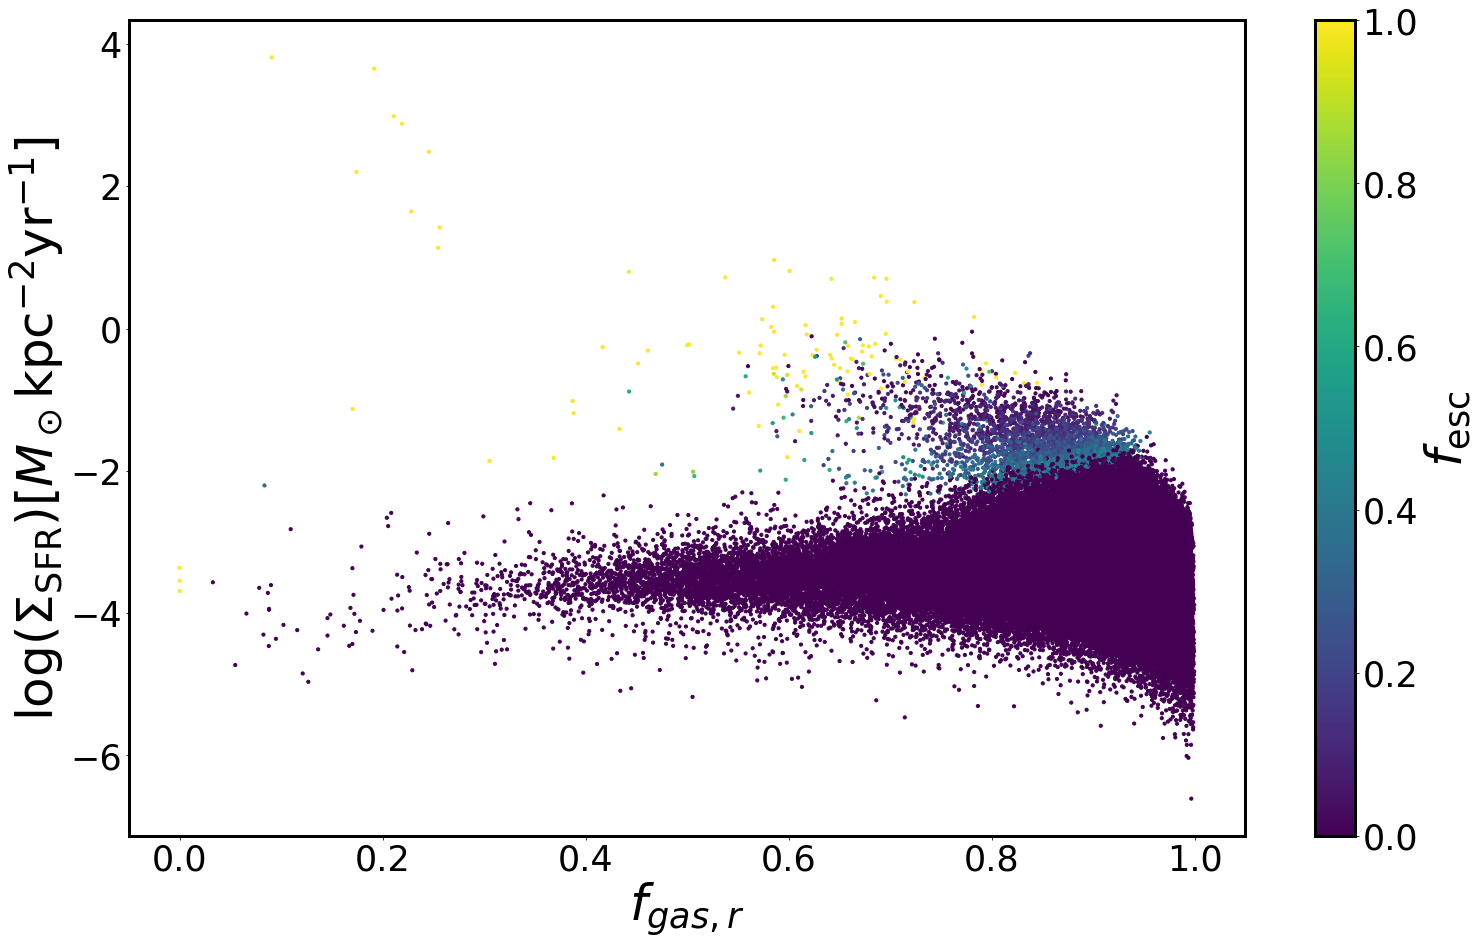

In [705]:
plt.scatter(df['f_g_r'], np.log10(df['Sigma_SFR_r']/conv**2), s=10, c=df['f_esc_r'])
plt.xlabel('$f_{gas,r}$', size=50)
plt.ylabel('$\log (\Sigma_\mathrm{SFR})[M_\odot\mathrm{kpc}^{-2}\mathrm{yr}^{-1}]$', size=50)
cbar = plt.colorbar()
cbar.set_label('$f_\mathrm{esc}$', size=50)

In [455]:
from astropy import constants

In [451]:
test_df[['M_gas_sf','SFR_sf','M_star_sf', 'V_sf' ,'Z_sf', 'M_gas_2r','SFR_2r','M_star_2r', 'V_gas_2r' ,'Z_2r']]

,M_gas_sf,SFR_sf,M_star_sf,V_sf,Z_sf,M_gas_2r,SFR_2r,M_star_2r,V_gas_2r,Z_2r
11642,3.290392e+38,0.088983,8.772462e+36,4.921752e+65,0.002214,4.001029e+38,0.088840,4.725922e+42,1.356197e+66,0.002046
11643,2.730061e+38,0.100428,1.775720e+37,2.284411e+65,0.002885,1.734530e+38,0.067313,5.489115e+42,2.930771e+65,0.003636
11644,1.917824e+38,0.046203,8.452027e+36,3.294481e+65,0.002648,2.239937e+38,0.043965,3.463720e+42,8.143030e+65,0.002666
11645,7.572045e+37,0.017684,4.305082e+36,1.286016e+65,0.002326,1.047919e+38,0.017453,1.702506e+42,4.793290e+65,0.002009
11648,1.742100e+37,0.002968,4.299958e+35,4.936932e+64,0.001532,2.128349e+37,0.002748,7.925460e+41,9.462819e+64,0.001504
...,...,...,...,...,...,...,...,...,...,...
12734,1.235582e+37,0.002069,1.365285e+35,3.638878e+64,0.000450,4.257291e+37,0.002069,1.467678e+41,4.521189e+65,0.000409
12735,1.638463e+37,0.003182,3.726886e+35,3.709624e+64,0.000772,1.764894e+37,0.002692,1.174142e+41,9.055707e+64,0.000786
12738,1.598729e+37,0.002645,1.854264e+35,4.813052e+64,0.000281,1.597642e+36,0.000201,5.870711e+40,5.983418e+63,0.000438
12739,2.016287e+36,0.000285,2.059344e+35,8.268444e+63,0.001246,2.347902e+37,0.000285,2.054749e+41,2.304596e+65,0.000912


In [382]:
x_label = r'$\log(N_r)[\log(\mathrm{cm}^{-2})]$'
y_label = r'p.d.f.($\log(N_r)$)'
labels = {'x':x_label, 'y':y_label}

In [390]:
x_label = '$\log(h_r)[\log(\mathrm{cm})]$'
y_label = r'p.d.f.($\log(h_r)$)'
labels = {'x':x_label, 'y':y_label}

In [694]:
x_label = '$f_{gas,r}$'
y_label = r'p.d.f.($f_{gas,r}$)'
labels = {'x':x_label, 'y':y_label}

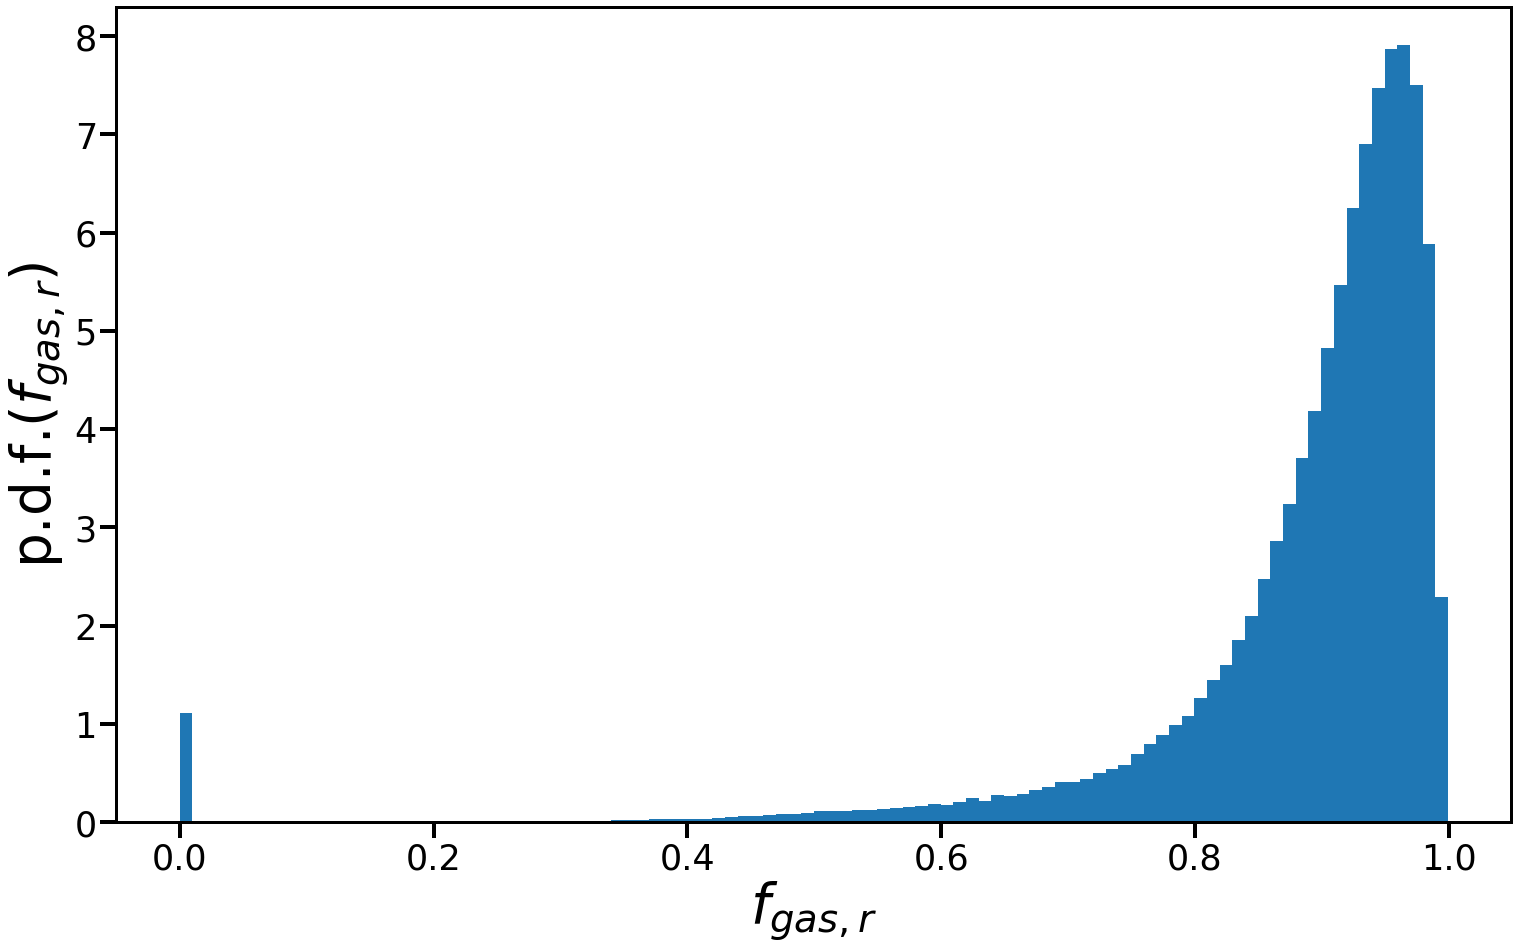

In [695]:
plot_histogram(df, prop='f_g_r', log=False, labels=labels)

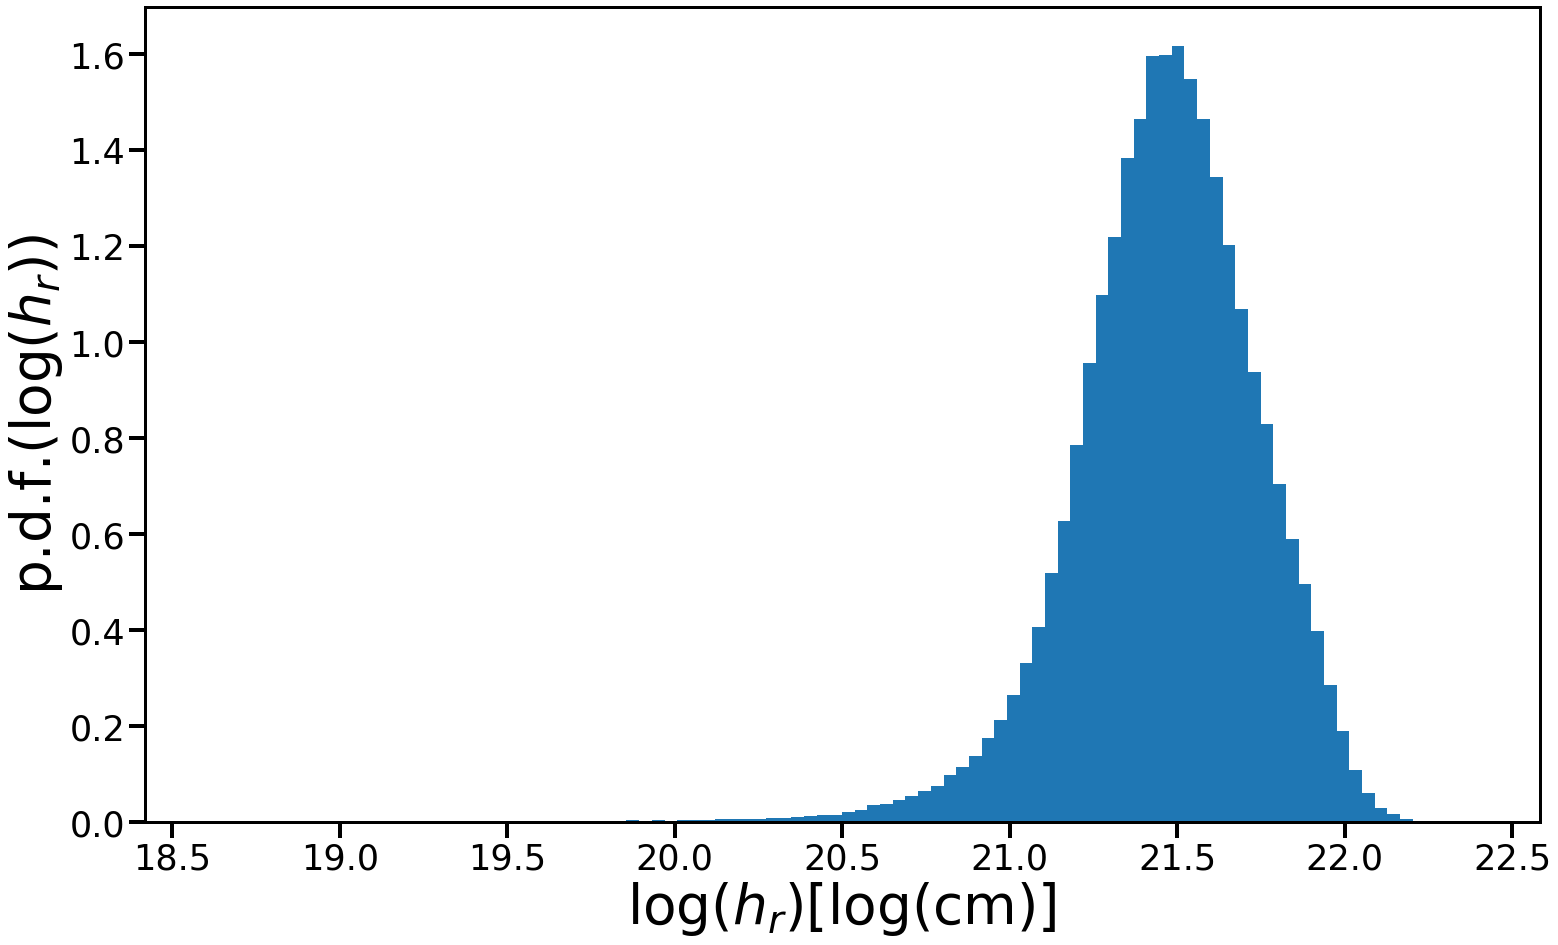

In [392]:
plot_histogram(df=df[df.Column_height_r != 0], prop='Column_height_r', log=True, labels=labels)

In [384]:
x_label = r'$\log(N_{2r})[\log(\mathrm{cm}^{-2})]$'
y_label = r'p.d.f.($\log(N_{2r})$)'
labels = {'x':x_label, 'y':y_label}

In [386]:
x_label = '$\log(h_{2r})[\log(\mathrm{cm})]$'
y_label = r'p.d.f.($\log(h_{2r})$)'
labels = {'x':x_label, 'y':y_label}

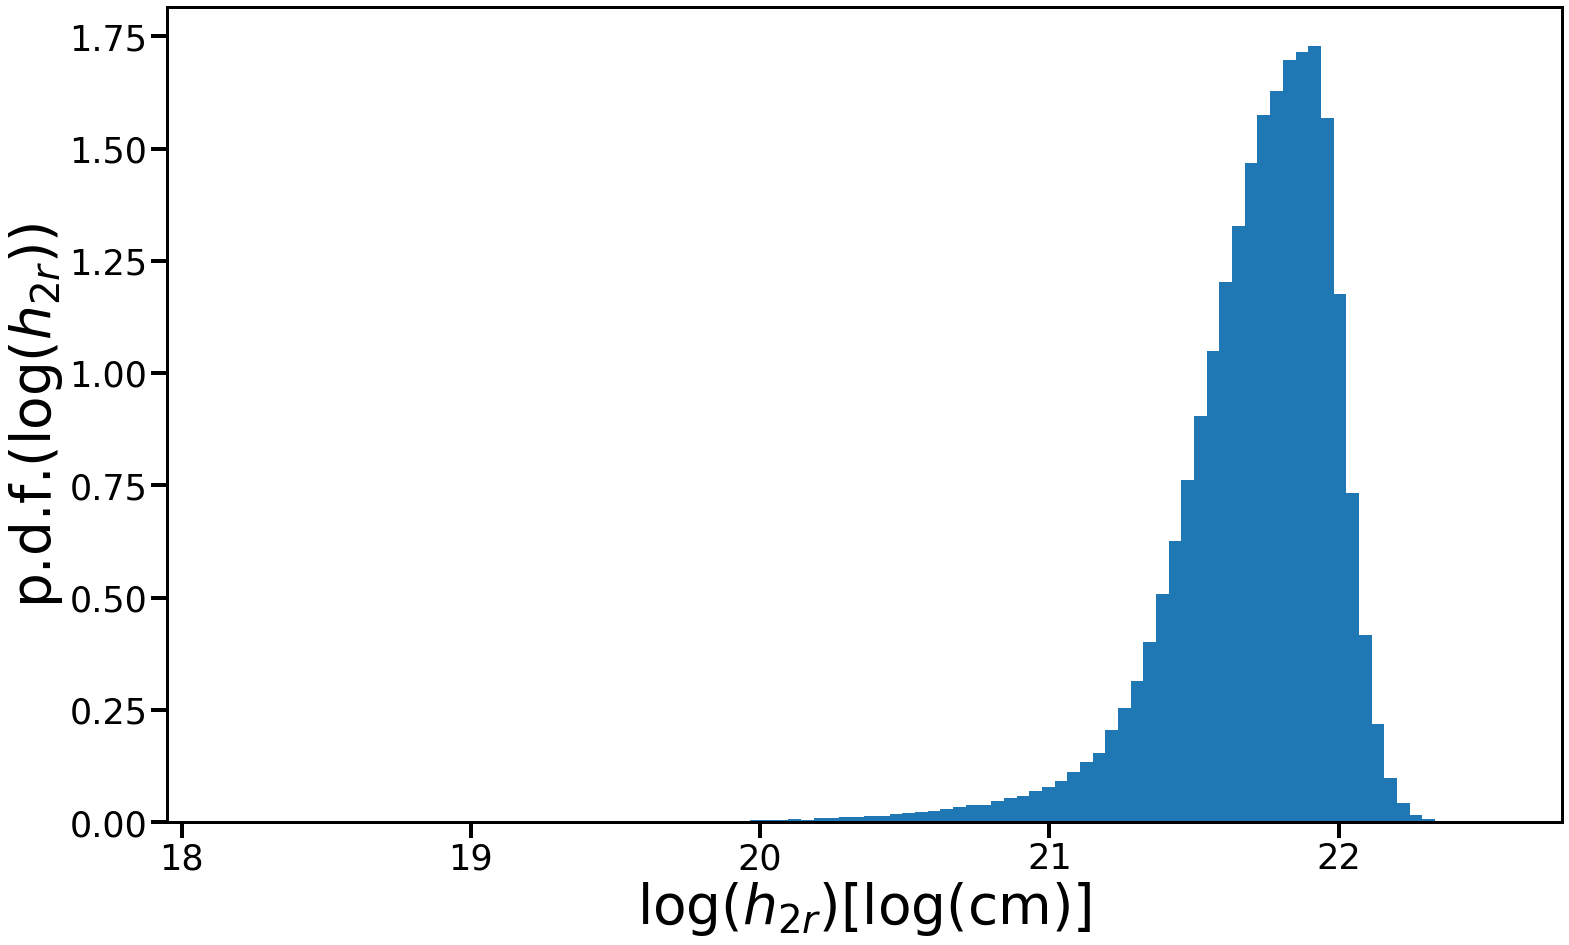

In [389]:
plot_histogram(df=df[df.Column_height_r != 0], prop='Column_height_2r', log=True, labels=labels)

In [388]:
df.Column_height_r.describe()

count    2.813490e+05
mean     3.420892e+21
std      2.090699e+21
min      0.000000e+00
25%      1.981654e+21
50%      2.965221e+21
75%      4.381284e+21
max      2.464664e+22
Name: Column_height_r, dtype: float64

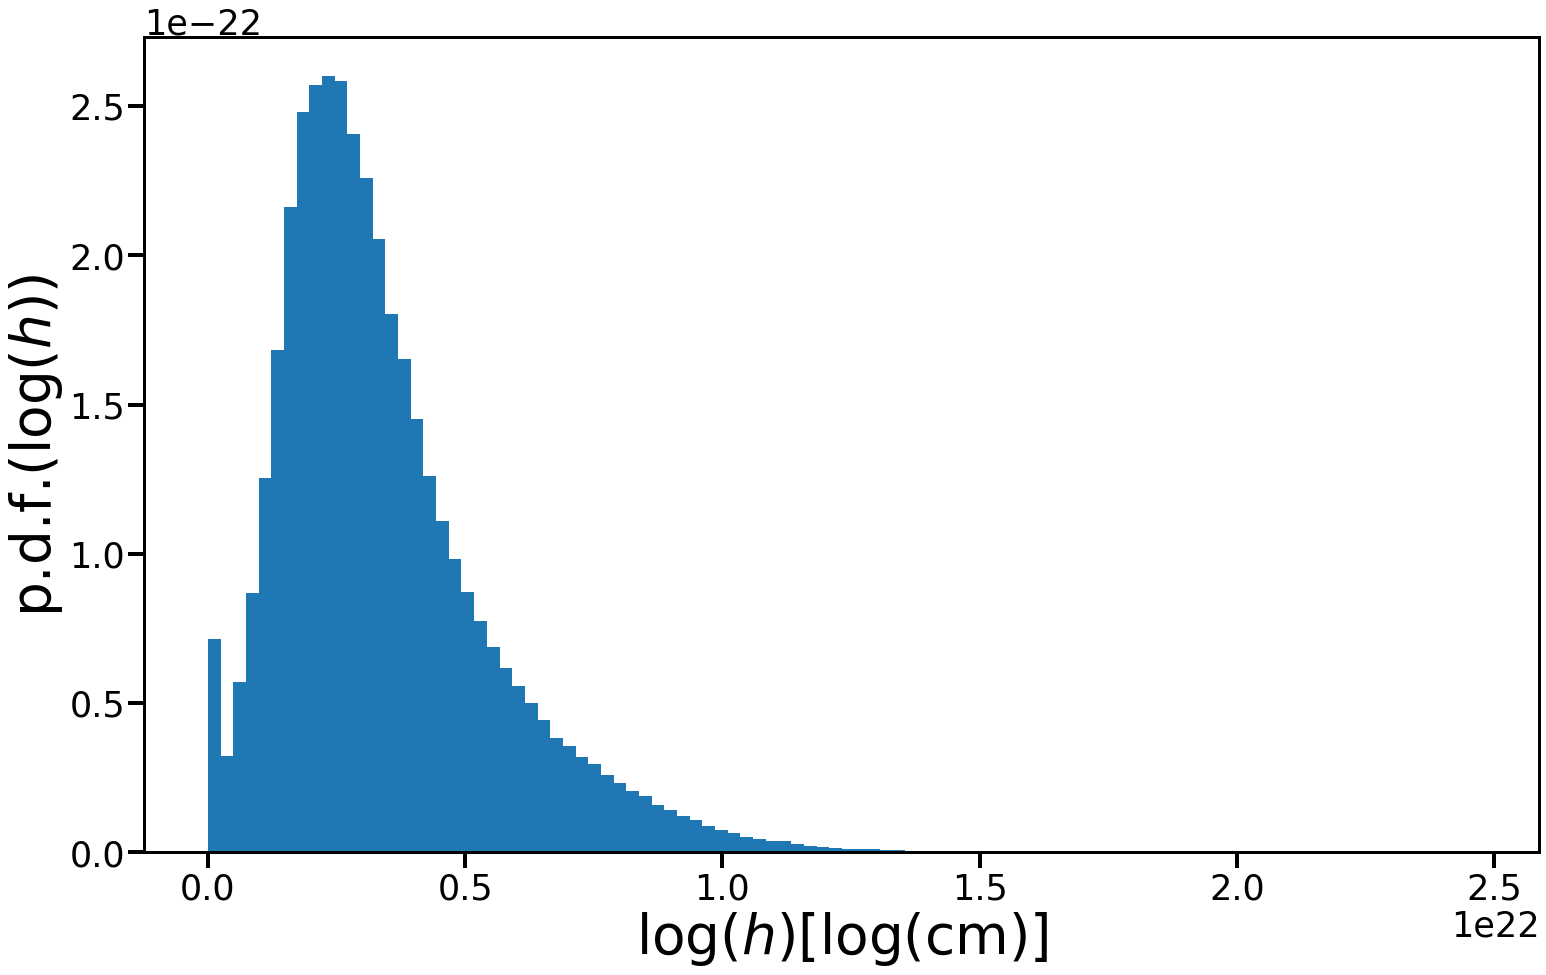

In [341]:
plot_histogram(df, prop='Column_height_r', log=False)

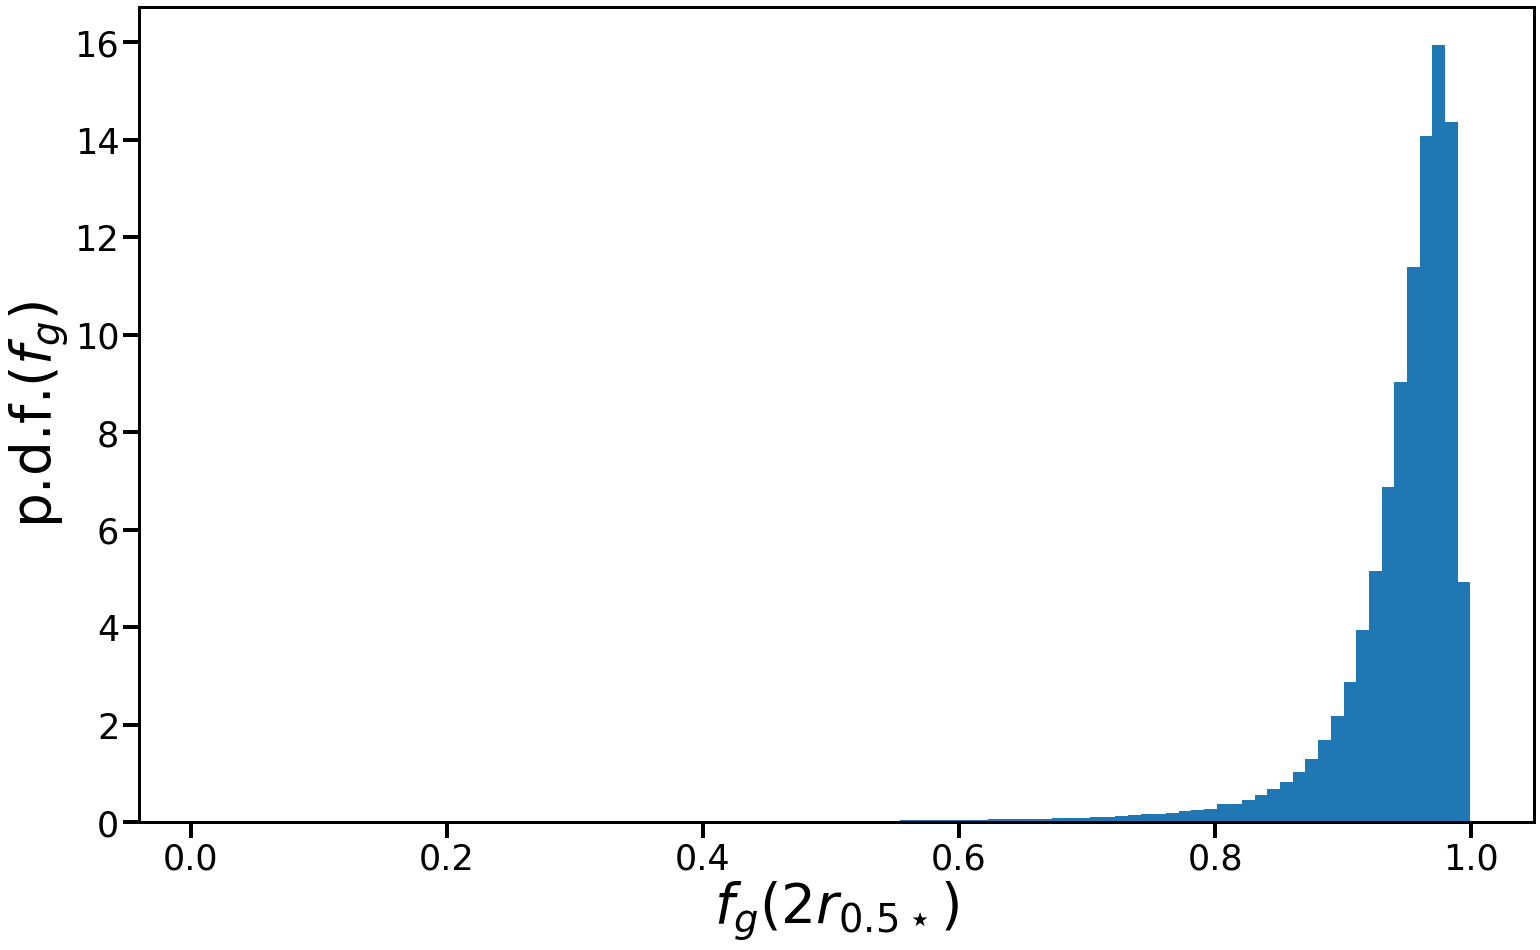

In [299]:
plot_histogram(df=df, prop='f_g_2r', labels=labels, log=False)